In [2]:
import pandas as pd
import os

# Lista de archivos CSV de cada video
csv_files = [
    "features_street_view_1.csv",
    "features_street_view_2.csv",
    "features_street_view_3.csv",
    "features_street_view_4.csv",
    "features_street_view_5.csv"
]

all_features = []
offset = 0

for file in csv_files:
    df = pd.read_csv(file)
    
    # Asegurar que track_id es int
    df["track_id"] = df["track_id"].astype(int)
    
    # Sumar offset para que sean únicos
    df["track_id"] = df["track_id"] + offset
    
    # Guardar max id para el próximo offset
    offset = df["track_id"].max() + 1
    
    all_features.append(df)

# Unir todo en un solo DataFrame
features_all = pd.concat(all_features, ignore_index=True)

# Guardar a CSV
features_all.to_csv("features_combinados.csv", index=False)
print("✅ Features combinados guardados con IDs únicos")

✅ Features combinados guardados con IDs únicos


In [3]:
features = pd.read_csv("features_combinados.csv")
# Eliminar los que tienen menos de 10 total_points
features = features[features["total_points"] >= 10]
features

,track_id,total_points,x_delta_min,x_delta_max,x_delta_avg,y_delta_min,y_delta_max,y_delta_avg,distance_min,distance_max,...,distance_bin_7,velocity_bin_7,x_delta_bin_8,y_delta_bin_8,distance_bin_8,velocity_bin_8,x_delta_bin_9,y_delta_bin_9,distance_bin_9,velocity_bin_9
0,1,927,-60.187170,46.936691,-0.037236,-76.815422,89.150706,-0.382840,0.164496,95.750580,...,0,35,2,2,0,3,24,50,76,0
1,2,3144,-1205.209903,136.551506,3.556468,-164.522964,34.769827,0.496587,0.782777,1215.496969,...,269,5,480,51,283,61,1217,160,339,96
2,3,1605,-262.360859,340.495165,0.254802,-109.845574,161.492007,-0.094763,0.131711,362.162196,...,128,16,83,125,28,4,153,247,293,88
3,4,833,-91.693889,28.988579,1.067226,-44.618829,59.074282,0.292130,0.575676,92.173342,...,2,6,60,12,4,10,117,15,59,0
4,5,949,-244.889218,212.984527,0.000000,-165.577804,210.803456,0.000000,0.110152,262.336037,...,9,32,79,16,12,5,111,83,188,105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43178,65363,252,-4.312092,4.536758,0.171153,-14.647238,10.340568,0.257410,0.121574,14.864851,...,0,0,0,0,0,0,0,0,0,0
43179,65364,438,-77.983663,15.513456,0.858917,-10.803360,29.899006,-0.252133,1.052566,82.398917,...,0,20,8,13,0,0,0,15,30,0
43180,65365,24,-9.341111,3.045809,-1.298863,-1.304963,1.181659,-0.184219,1.222107,9.431823,...,0,0,0,0,0,0,0,0,0,0
43181,65367,39,-21.021073,18.232118,-3.072165,-14.694371,15.498470,-3.576227,2.259540,24.007230,...,0,0,2,2,0,0,0,0,0,0


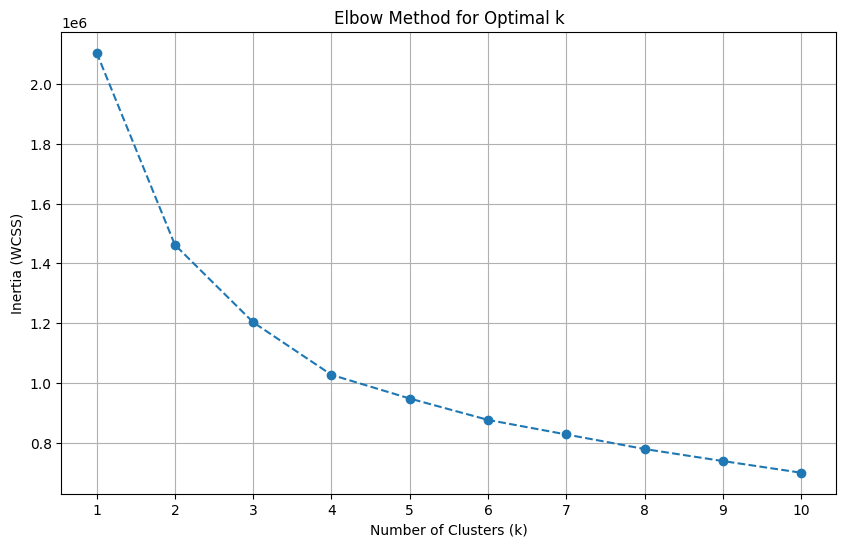

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from joblib import dump, load

columns_to_filter_out = ['track_id']

# Guarda el track_id antes de eliminar columnas y NaNs
clean_features = features.dropna()
track_ids_clean = clean_features['track_id'].reset_index(drop=True)

# Create a new DataFrame by dropping the specified columns
# The .drop() method returns a new DataFrame without the specified columns.
df_selected = clean_features.drop(columns=columns_to_filter_out).reset_index(drop=True)


# --- Step 3: Data Scaling ---
# K-Means is sensitive to the scale of features. We scale the remaining features.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_selected)
dump(scaler, 'scaler_kmeans.joblib')  # Save the scaler for future use

# --- Step 4: The Elbow Method to Find Optimal k ---
# We will run K-Means for a range of k values and calculate the inertia (WCSS).
inertia_values = []
k_range = range(1, 11) # Test k from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k,
                    init='k-means++',
                    n_init=10,
                    max_iter=300,
                    random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# --- Step 5: Plot the Elbow Curve ---
# The "elbow" is the point where the rate of decrease in inertia sharply slows down.
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [5]:
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k,
                      init='k-means++',
                      n_init=10,
                      max_iter=300,
                      random_state=42)

# Fit the model and predict the cluster for each data point
cluster_labels = final_kmeans.fit_predict(X_scaled)

# Add the cluster labels back to our selected DataFrame
df_selected['cluster'] = cluster_labels

# Add the track_id back to the DataFrame
df_selected['track_id'] = track_ids_clean

print("\nClustering complete. Cluster labels added to the DataFrame.")
print(df_selected.head())


Clustering complete. Cluster labels added to the DataFrame.
   total_points  x_delta_min  x_delta_max  x_delta_avg  y_delta_min  \
0           927   -60.187170    46.936691    -0.037236   -76.815422   
1          3144 -1205.209903   136.551506     3.556468  -164.522964   
2          1605  -262.360859   340.495165     0.254802  -109.845574   
3           833   -91.693889    28.988579     1.067226   -44.618829   
4           949  -244.889218   212.984527     0.000000  -165.577804   

   y_delta_max  y_delta_avg  distance_min  distance_max  distance_avg  ...  \
0    89.150706    -0.382840      0.164496     95.750580     11.930941  ...   
1    34.769827     0.496587      0.782777   1215.496969     37.494009  ...   
2   161.492007    -0.094763      0.131711    362.162196     33.251984  ...   
3    59.074282     0.292130      0.575676     92.173342     16.844178  ...   
4   210.803456     0.000000      0.110152    262.336037     37.063407  ...   

   x_delta_bin_8  y_delta_bin_8  distance_b

In [16]:
# Promedio de features por cluster
cluster_summary = df_selected.groupby('cluster')[df_selected.columns].mean()

pd.set_option("display.max_columns", None)  # para que no oculte columnas
print(cluster_summary.round(2))

         total_points  x_delta_min  x_delta_max  x_delta_avg  y_delta_min  \
cluster                                                                     
0             4248.99      -256.83       183.25         0.26      -104.22   
1          2405624.88      -245.33       408.97        -0.00       -96.12   
2           623387.44      -297.17       451.26        -0.00      -133.88   

         y_delta_max  y_delta_avg  distance_min  distance_max  distance_avg  \
cluster                                                                       
0              85.23         0.05          2.51        361.86         26.13   
1             119.51        -0.00          0.01        585.47          7.09   
2             136.93        -0.00          0.01        604.89          7.17   

         velocity_min  velocity_max  velocity_avg  x_delta_bin_0  \
cluster                                                            
0                0.25         36.19          2.61         281.99   
1             

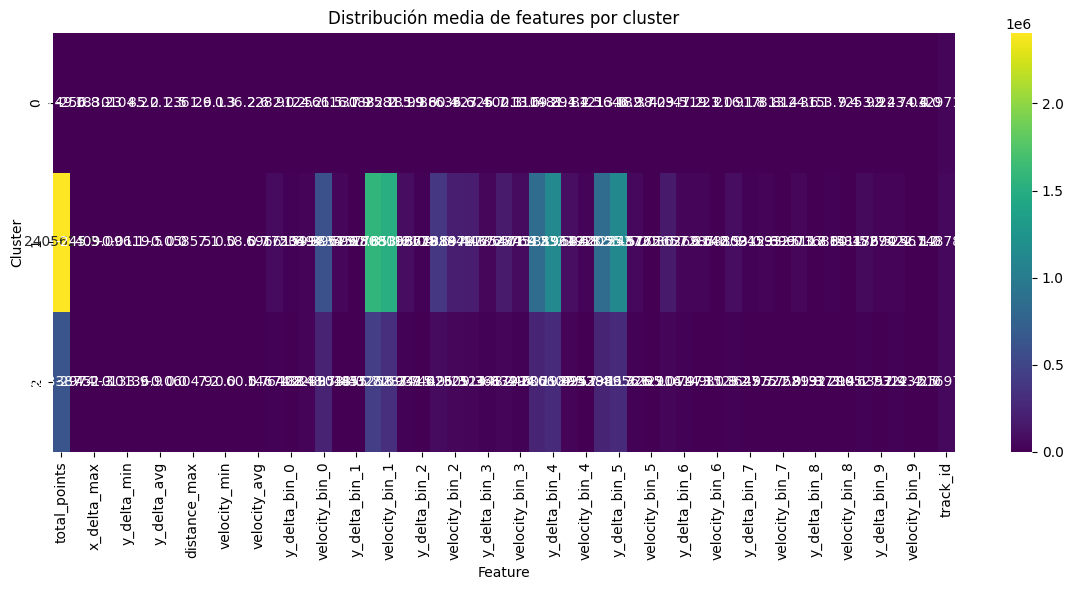

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_summary, cmap='viridis', annot=True, fmt=".1f")
plt.title("Distribución media de features por cluster")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

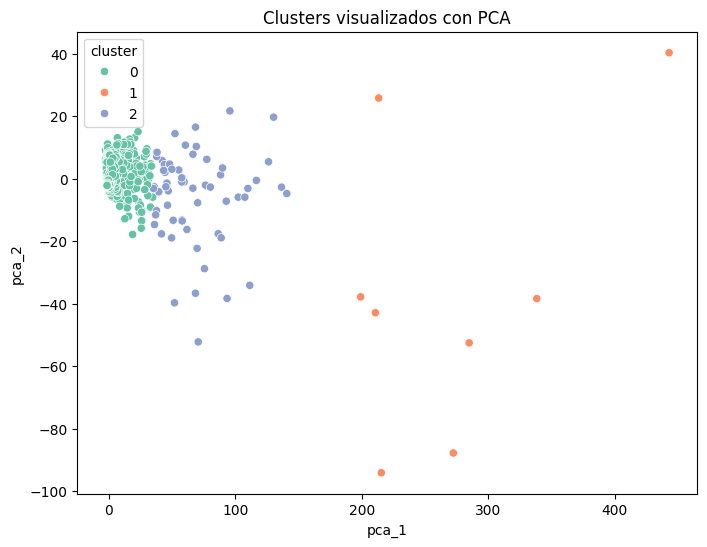

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_selected['pca_1'] = X_pca[:, 0]
df_selected['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_selected, x='pca_1', y='pca_2', hue='cluster', palette='Set2')
plt.title("Clusters visualizados con PCA")
plt.show()

In [9]:
# Cada fila es un componente principal (pca_1, pca_2)
# Cada columna es una feature original

# Features sin track_id
pca_x = features.drop(columns='track_id')
loadings = pd.DataFrame(pca.components_, columns=pca_x.columns, index=['pca_1', 'pca_2'])

print(loadings.T.sort_values(by='pca_1', ascending=False).head(10))  # top contribuyentes a pca_1
print(loadings.T.sort_values(by='pca_2', ascending=False).head(10))  # top contribuyentes a pca_2

                   pca_1     pca_2
velocity_bin_2  0.180453 -0.005506
distance_bin_4  0.179742 -0.004499
distance_bin_3  0.178597 -0.041043
distance_bin_5  0.178462  0.009631
distance_bin_6  0.175415  0.022518
x_delta_bin_2   0.174173 -0.045475
velocity_bin_3  0.173118  0.039230
x_delta_bin_1   0.172625 -0.009426
x_delta_bin_7   0.171235 -0.040678
distance_bin_2  0.170316 -0.092229
                   pca_1     pca_2
distance_max    0.044559  0.367723
velocity_max    0.044559  0.367723
x_delta_max     0.038120  0.277965
y_delta_max     0.034120  0.230244
distance_avg   -0.005424  0.216934
velocity_avg   -0.005424  0.216934
velocity_bin_9  0.119166  0.168994
velocity_bin_7  0.108417  0.128781
distance_bin_9  0.162037  0.124655
velocity_bin_6  0.129408  0.121147


/var/folders/7q/w_6v_j9n1kndf51lbvslc8b00000gn/T/ipykernel_66043/2918758970.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loadings.columns, y=loadings.loc['pca_1'].abs(), palette='viridis')


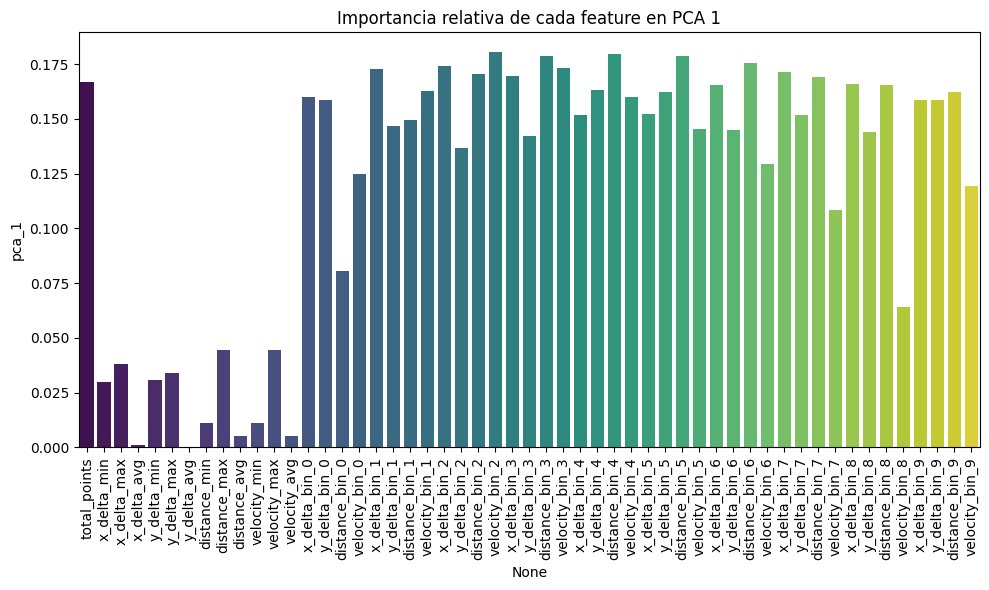

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x=loadings.columns, y=loadings.loc['pca_1'].abs(), palette='viridis')
plt.title("Importancia relativa de cada feature en PCA 1")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


/var/folders/7q/w_6v_j9n1kndf51lbvslc8b00000gn/T/ipykernel_66043/4262070556.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loadings.columns, y=loadings.loc['pca_2'].abs(), palette='viridis')


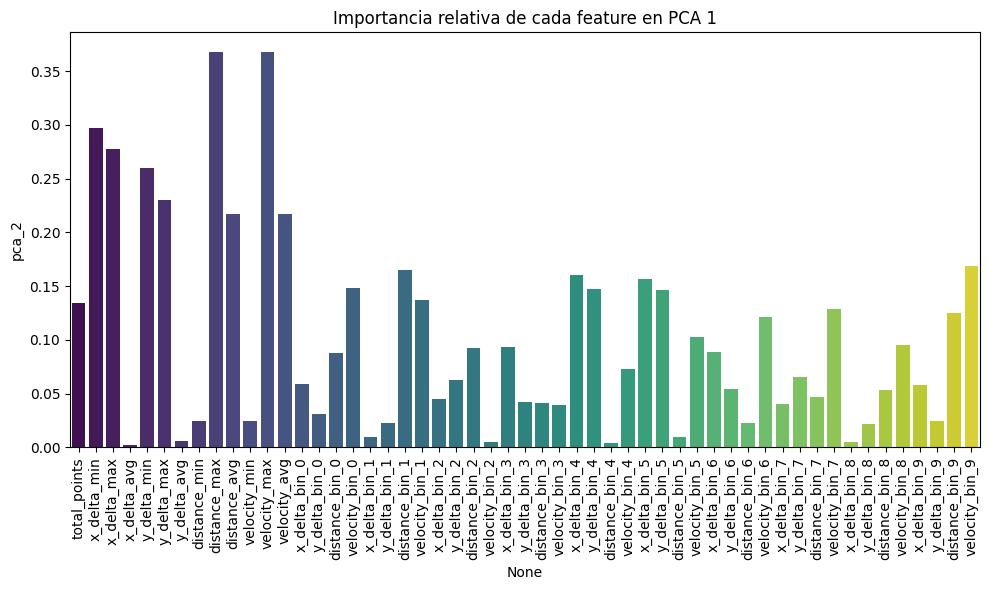

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(x=loadings.columns, y=loadings.loc['pca_2'].abs(), palette='viridis')
plt.title("Importancia relativa de cada feature en PCA 1")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [12]:
# Rango (max - min) por feature entre clusters
importance = cluster_summary.max() - cluster_summary.min()
importance.sort_values(ascending=False).head(10)

total_points      2.401376e+06
distance_bin_1    1.575771e+06
velocity_bin_1    1.505487e+06
y_delta_bin_4     1.130433e+06
y_delta_bin_5     1.120840e+06
x_delta_bin_4     8.440137e+05
x_delta_bin_5     8.408425e+05
velocity_bin_0    5.992684e+05
distance_bin_2    3.770090e+05
velocity_bin_2    1.978430e+05
dtype: float64

In [13]:
from joblib import dump, load

# Guardar modelo
dump(final_kmeans, 'modelo_kmeans.joblib')

['modelo_kmeans.joblib']

In [14]:
# Guardar el PCA
dump(pca, 'pca_modelo.joblib')

['pca_modelo.joblib']

In [15]:
# Buscar track ids del cluster 1
df_selected[df_selected['cluster'] == 1]

,total_points,x_delta_min,x_delta_max,x_delta_avg,y_delta_min,y_delta_max,y_delta_avg,distance_min,distance_max,distance_avg,velocity_min,velocity_max,velocity_avg,x_delta_bin_0,y_delta_bin_0,distance_bin_0,velocity_bin_0,x_delta_bin_1,y_delta_bin_1,distance_bin_1,velocity_bin_1,x_delta_bin_2,y_delta_bin_2,distance_bin_2,velocity_bin_2,x_delta_bin_3,y_delta_bin_3,distance_bin_3,velocity_bin_3,x_delta_bin_4,y_delta_bin_4,distance_bin_4,velocity_bin_4,x_delta_bin_5,y_delta_bin_5,distance_bin_5,velocity_bin_5,x_delta_bin_6,y_delta_bin_6,distance_bin_6,velocity_bin_6,x_delta_bin_7,y_delta_bin_7,distance_bin_7,velocity_bin_7,x_delta_bin_8,y_delta_bin_8,distance_bin_8,velocity_bin_8,x_delta_bin_9,y_delta_bin_9,distance_bin_9,velocity_bin_9,cluster,track_id,pca_1,pca_2
28122,3419187,-492.470632,68.548985,0.000275,-61.601374,18.386656,0.000070,0.015617,496.144143,4.925967,0.001562,49.614414,0.492597,75917,2926,14062,650040,42310,1848,2475708,2471681,80646,1927,491373,231100,209980,26408,194714,52229,1276771,1656108,104441,9166,1263639,1695472,64293,1337,243276,30341,36603,543,105941,2902,15794,221,62603,1245,11190,550,58094,0,10999,2310,1,46509,272.324092,-87.752627
29731,3192409,-94.282598,63.547360,0.000092,-17.467537,20.356971,-0.000045,0.011206,94.970746,4.205647,0.001121,9.497075,0.420565,38399,0,22230,737082,36159,622,2397115,2267930,70647,2485,480605,141846,220167,13658,144533,33404,1266675,1590446,63844,10046,1185351,1554921,34538,2002,239004,27129,21896,77,64287,3032,9989,2,27980,105,8359,10,43730,1,9290,0,1,49232,215.421873,-94.075920
30095,2641727,-254.980103,59.230096,0.000350,-65.310128,86.820788,-0.000128,0.011671,255.199524,6.453794,0.001167,25.519952,0.645379,28279,40541,8716,369667,32419,17136,1590279,1958681,94946,27597,563019,226893,262568,76554,225597,60741,856209,1179350,100940,13808,969928,1130943,57449,6991,225874,79966,36285,1771,96483,25797,23461,104,40570,17654,13744,140,34441,46179,22227,2921,1,49833,338.274321,-38.378587
32008,2642876,-54.198962,1422.656389,-0.005312,-54.455759,286.783103,-0.000662,0.004889,1433.255458,4.925112,0.000489,143.325546,0.492511,100112,9531,84280,1700989,33971,2795,2201320,758527,42065,19601,124416,88557,75460,82020,65086,58269,1148654,1315695,39294,27951,1194524,1184035,30947,2073,29407,11000,27695,2,8840,4989,24350,8,2355,524,16891,0,7478,12676,28587,6490,1,52908,210.717083,-42.896921
34651,2047212,-713.825664,64.373738,0.001282,-332.936848,158.547758,0.000740,0.003911,784.070730,5.428202,0.000391,78.407073,0.542820,15542,20472,26071,522474,17771,6969,1415351,1358482,49905,11821,340139,117715,141146,35796,134321,22131,736387,889318,54802,17133,808208,998010,26227,4598,172191,45542,11466,1420,72926,8604,7659,191,18315,4165,9461,105,14811,26505,21705,2953,1,57215,199.115541,-37.825282
35558,891976,-234.287174,356.293905,-0.003049,-79.433202,71.655726,0.000140,0.009914,358.115422,12.097112,0.000991,35.811542,1.209711,85202,15147,5687,159544,33012,6945,381255,437500,53801,8294,142392,155767,69737,20683,96022,88517,218842,393020,68509,37135,205610,398076,52318,8087,65389,21962,41511,2252,37482,8870,36235,1872,27781,5261,26114,194,95110,13708,41923,1098,1,58707,213.338161,25.772361
36359,2447831,-41.022631,543.433748,-0.001576,-73.883123,215.797204,-0.000585,0.003530,565.519270,6.891057,0.000353,56.551927,0.689106,57907,19519,20472,484862,44038,5227,1421150,1638650,128750,11714,481286,240842,286517,53593,258753,67396,837109,1164949,103713,10345,693470,1137016,69321,1268,174311,19436,46638,1328,110316,9588,24155,0,49987,4381,10455,0,65416,22398,11878,3130,1,59977,284.836619,-52.542628
39260,1961781,-77.573873,693.649615,-0.000369,-83.841519,97.702367,-0.000020,0.002875,696.447811,11.830198,0.000287,69.644781,1.183020,155935,31902,6438,174021,77710,6200,739051,1173093,134971,13990,399885,385117,207811,46264,284745,143469,420341,866430,181359,49802,415714,881423,107884,19820,175809,54781,76188,9782,134549,23519,54626,4898,90199,7606,38827,133,148732,29656,72768,1636,1,64644,442.859649,4

In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import cdist

# --- 1. Percentage of Class 1 ---
key_class = 1 
total_points = len(df_selected)
class1_points = np.sum(df_selected["cluster"] == key_class)
perc_class1 = 100 * class1_points / total_points

print(f"Cluster {key_class} (suspicious) represents {perc_class1:.2f}% of all trajectories.")

# --- 2. Distance between centroids ---

centroids = final_kmeans.cluster_centers_

# Compute pairwise Euclidean distances between centroids
centroid_dists = cdist(centroids, centroids)

# Extract distances from key cluster to others
distances_from_class1 = centroid_dists[key_class, :]
print("\nDistances from cluster 1 to others:")
for i, d in enumerate(distances_from_class1):
    if i != key_class:
        print(f"  To cluster {i}: {d:.4f}")

# Average distance (how isolated cluster 1 is)
mean_dist_from_class1 = np.mean([d for i, d in enumerate(distances_from_class1) if i != key_class])
print(f"\nAverage distance from cluster 1 to others: {mean_dist_from_class1:.4f}")

# --- Additional comparison: distance between cluster 0 and 2 ---
cluster_a, cluster_b = 0, 2
distance_0_2 = centroid_dists[cluster_a, cluster_b]
print(f"\nDistance between cluster {cluster_a} and cluster {cluster_b}: {distance_0_2:.4f}")

# Compare to distances from key cluster
if key_class in [cluster_a, cluster_b]:
    print("Note: One of the compared clusters is your key class.")
else:
    diff_vs_key = abs(distance_0_2 - mean_dist_from_class1)
    print(f"Distance (0–2) differs from mean distance of cluster {key_class} by {diff_vs_key:.4f}")


# --- 3. Internal validation metrics ---
silhouette = silhouette_score(X_scaled, cluster_labels)
davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels)
calinski = calinski_harabasz_score(X_scaled, cluster_labels)

print(f"\nSilhouette score: {silhouette:.4f}  (higher = better separation)")
print(f"Davies–Bouldin index: {davies_bouldin:.4f}  (lower = better)")
print(f"Calinski–Harabasz index: {calinski:.4f}  (higher = better)")

Cluster 1 (suspicious) represents 0.02% of all trajectories.

Distances from cluster 1 to others:
  To cluster 0: 276.7337
  To cluster 2: 210.6425

Average distance from cluster 1 to others: 243.6881

Distance between cluster 0 and cluster 2: 70.1993
Distance (0–2) differs from mean distance of cluster 1 by 173.4888

Silhouette score: 0.9389  (higher = better separation)
Davies–Bouldin index: 0.8978  (lower = better)
Calinski–Harabasz index: 14901.7018  (higher = better)
